In [29]:
import unicodedata
import re
def preprocess_text(file_path):
    try:
        with open(file_path, 'r', encoding='gb18030') as f:
            data = f.read().replace('\n', '')
            # 规范化文本并去除全角空格
            data = unicodedata.normalize('NFKC', data).replace(' ', '')
            return data
    except FileNotFoundError:
        return "文件未找到，请检查文件路径是否正确。"
#分句    
def sents_split(text):
    # 使用正则表达式分割句号和逗号
    sents = re.split(r'[。, ;]', text)
    # 移除结果中的空字符串
    sents = [sent.strip() for sent in sents if sent.strip()]
    return sents

if __name__ == "__main__":
    file_path = r'.\自然语言处理实验2-实验数据.txt'
    processed_text = preprocess_text(file_path)
    sents = sents_split(processed_text)
    for sent in sents:
        print(sent)

记者从国家航天局获悉
5月21日16时00分
我国在酒泉卫星发射中心采用长征二号丙运载火箭
成功发射首颗内地与澳门合作研制的空间科学卫星“澳门科学一号”
该卫星作为国际首颗低纬度地磁场与空间环境的科学探测卫星
国内地球磁场探测精度最高的卫星
将显著提高我国空间磁测技术水平
该项目由国家航天局与澳门特别行政区政府联合开展
探测数据由双方共享
开辟了内地同澳门在航天等创新科技领域开展合作的新路径
拓展了以内地为基础、澳门为窗口开展空间科学、空间技术、空间应用广泛合作交流的新空间
为粤港澳大湾区区域发展和航天高质量发展增添了新动能
“澳门科学一号”卫星项目鼓励科学数据的开放共享和应用
将通过相关数据政策
促进与国内外科研机构开展广泛合作
产出更多科学研究成果
加强人才联合培养和交流
未来还会持续推动航天科学研究与澳门青少年航天科普知识教育工作


In [25]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_dependency_graph(words, heads, labels):
    # 创建有向图
    G = nx.DiGraph()

    # 添加节点和边
    for word, head, label in zip(words, heads, labels):
        G.add_node(word)
        if head > 0:  # 排除根节点
            G.add_edge(words[head - 1], word, label=label)

    # 绘制图形
    pos = nx.spring_layout(G, seed=42)  # 定义布局
    nx.draw(G, pos, with_labels=True, node_size=1500, node_color='lightblue', font_size=10)

    # 添加边的标签
    edge_labels = {(tail, head): G[tail][head]['label'] for tail, head in G.edges}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

    plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
    plt.show()

Loading weights from local directory
分词结果：[['记者', '从', '国家', '航天局', '获悉']]
词性标注结果：[['n', 'p', 'n', 'n', 'v']]
命名实体识别结果：[[('Ni', '国家航天局')]]
语义角色标注结果：[[{'predicate': '获悉', 'arguments': [('A0', '记者'), ('A2', '从国家航天局')]}]]
依存句法分析结果：[{'head': [5, 5, 4, 2, 0], 'label': ['SBV', 'ADV', 'ATT', 'POB', 'HED']}]
语义依存分析结果：[{'head': [5, 4, 4, 5, 0], 'label': ['AGT', 'mRELA', 'FEAT', 'DATV', 'Root']}]
语义依存图分析结果：[[(1, 5, 'AGT'), (2, 4, 'mRELA'), (3, 4, 'FEAT'), (4, 5, 'DATV'), (5, 0, 'Root')]]



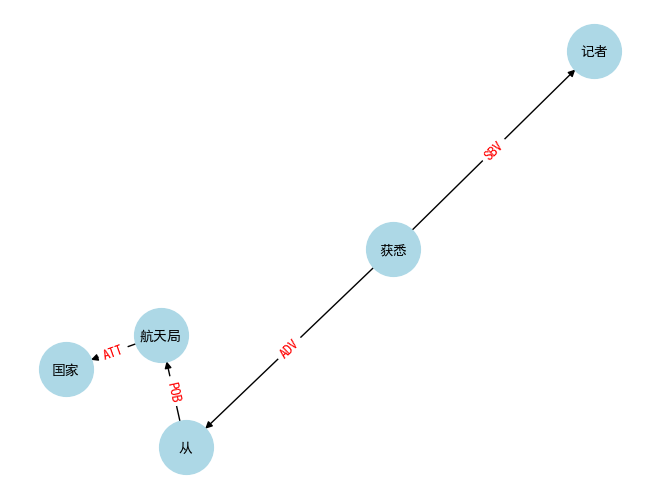

分词结果：[['5月', '21日', '16时', '00分']]
词性标注结果：[['nt', 'nt', 'nt', 'nt']]
命名实体识别结果：[[]]
语义角色标注结果：[[]]
依存句法分析结果：[{'head': [2, 4, 4, 0], 'label': ['ATT', 'ATT', 'ATT', 'HED']}]
语义依存分析结果：[{'head': [2, 4, 4, 0], 'label': ['FEAT', 'FEAT', 'FEAT', 'Root']}]
语义依存图分析结果：[[(1, 2, 'FEAT'), (1, 3, 'FEAT'), (2, 4, 'FEAT'), (3, 4, 'FEAT'), (4, 0, 'Root')]]



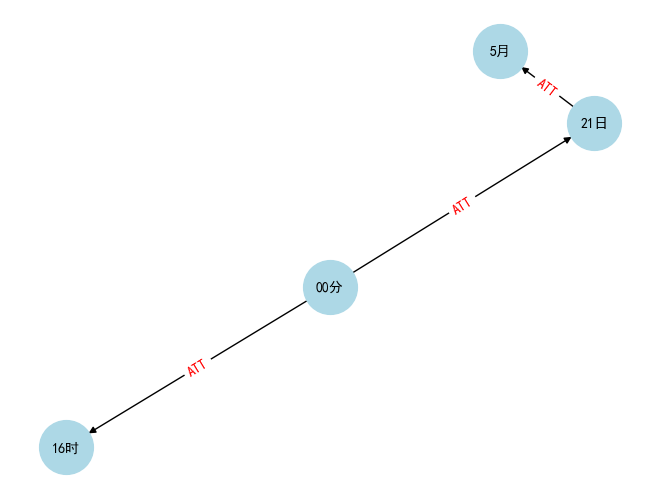

分词结果：[['我国', '在', '酒泉', '卫星', '发射', '中心', '采用', '长征二号丙', '运载火箭']]
词性标注结果：[['n', 'p', 'ns', 'n', 'v', 'n', 'v', 'nz', 'i']]
命名实体识别结果：[[('Ni', '卫星发射')]]
语义角色标注结果：[[{'predicate': '采用', 'arguments': [('A0', '我国'), ('ARGM-LOC', '在酒泉卫星发射中心'), ('A1', '长征二号丙运载火箭')]}]]
依存句法分析结果：[{'head': [7, 7, 6, 5, 6, 2, 0, 9, 7], 'label': ['SBV', 'ADV', 'ATT', 'FOB', 'ATT', 'POB', 'HED', 'ATT', 'VOB']}]
语义依存分析结果：[{'head': [7, 6, 6, 5, 6, 7, 0, 9, 7], 'label': ['AGT', 'mRELA', 'FEAT', 'PAT', 'dFEAT', 'LOC', 'Root', 'FEAT', 'CONT']}]
语义依存图分析结果：[[(1, 7, 'AGT'), (2, 6, 'mRELA'), (3, 6, 'FEAT'), (4, 5, 'PAT'), (5, 6, 'dFEAT'), (6, 7, 'LOC'), (7, 0, 'Root'), (8, 9, 'FEAT'), (9, 7, 'CONT')]]



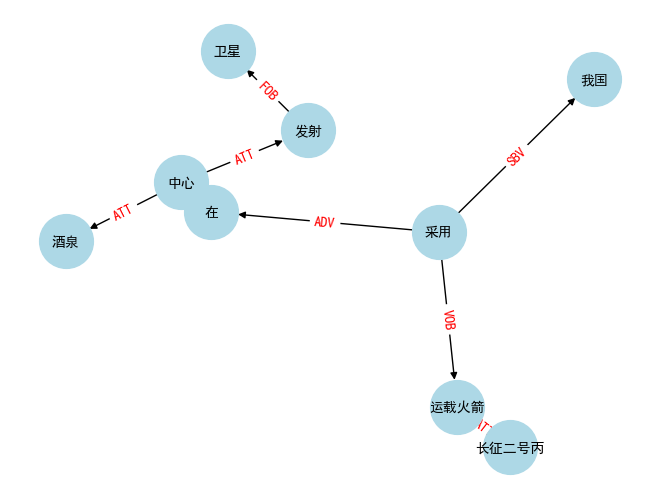

分词结果：[['成功', '发射', '首', '颗', '内地', '与', '澳门', '合作', '研制', '的', '空间科学', '卫星', '“', '澳门', '科学', '一号', '”']]
词性标注结果：[['a', 'v', 'm', 'q', 'nl', 'p', 'ns', 'v', 'v', 'u', 'n', 'n', 'wp', 'ns', 'n', 'm', 'wp']]
命名实体识别结果：[[('Ns', '澳门'), ('Ns', '澳门')]]
语义角色标注结果：[[{'predicate': '发射', 'arguments': [('ARGM-ADV', '成功'), ('A1', '首颗内地与澳门合作研制的空间科学卫星“澳门科学一号”')]}, {'predicate': '研制', 'arguments': [('A0', '内地与澳门')]}]]
依存句法分析结果：[{'head': [2, 0, 4, 12, 8, 7, 5, 12, 8, 8, 12, 16, 16, 15, 16, 2, 16], 'label': ['ADV', 'HED', 'ATT', 'ATT', 'SBV', 'LAD', 'COO', 'ATT', 'COO', 'RAD', 'ATT', 'ATT', 'WP', 'ATT', 'ATT', 'VOB', 'WP']}]
语义依存分析结果：[{'head': [2, 0, 4, 12, 8, 7, 8, 12, 12, 9, 12, 2, 12, 15, 12, 12, 16], 'label': ['MANN', 'Root', 'MEAS', 'MEAS', 'AGT', 'mRELA', 'DATV', 'rPAT', 'rCONT', 'mDEPD', 'FEAT', 'PAT', 'mPUNC', 'FEAT', 'FEAT', 'FEAT', 'mPUNC']}]
语义依存图分析结果：[[(1, 2, 'MANN'), (2, 0, 'Root'), (3, 4, 'MEAS'), (4, 12, 'MEAS'), (5, 8, 'AGT'), (6, 7, 'mRELA'), (7, 8, 'DATV'), (8, 12, 'rPAT'), (9, 8, 'eSUC

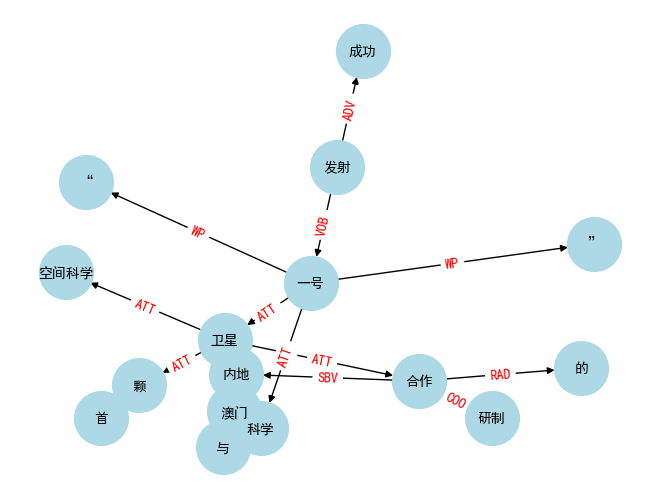

分词结果：[['该', '卫星', '作为', '国际', '首', '颗', '低纬度', '地磁场', '与', '空间', '环境', '的', '科学', '探测', '卫星']]
词性标注结果：[['r', 'n', 'p', 'n', 'm', 'q', 'n', 'n', 'c', 'n', 'n', 'u', 'n', 'v', 'n']]
命名实体识别结果：[[]]
语义角色标注结果：[[]]
依存句法分析结果：[{'head': [2, 3, 0, 6, 6, 15, 8, 15, 11, 11, 8, 8, 14, 15, 3], 'label': ['ATT', 'SBV', 'HED', 'ATT', 'ATT', 'ATT', 'ATT', 'ATT', 'LAD', 'ATT', 'COO', 'RAD', 'ADV', 'ATT', 'VOB']}]
语义依存分析结果：[{'head': [2, 3, 0, 15, 6, 15, 8, 11, 11, 11, 15, 11, 14, 15, 3], 'label': ['SCO', 'EXP', 'Root', 'SCO', 'MEAS', 'MEAS', 'FEAT', 'eCOO', 'mRELA', 'FEAT', 'FEAT', 'mDEPD', 'MANN', 'dFEAT', 'LINK']}]
语义依存图分析结果：[[(1, 2, 'SCO'), (2, 3, 'EXP'), (3, 0, 'Root'), (4, 15, 'SCO'), (5, 6, 'MEAS'), (6, 15, 'MEAS'), (7, 8, 'FEAT'), (8, 11, 'eCOO'), (9, 11, 'mRELA'), (10, 11, 'FEAT'), (11, 15, 'FEAT'), (12, 11, 'mDEPD'), (13, 14, 'MANN'), (14, 15, 'dFEAT'), (15, 3, 'LINK')]]



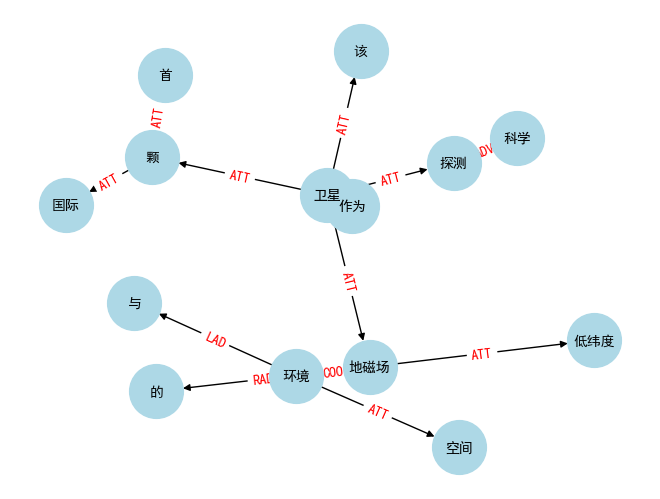

分词结果：[['国内', '地球', '磁场', '探测', '精度', '最高', '的', '卫星']]
词性标注结果：[['nl', 'n', 'n', 'v', 'n', 'a', 'u', 'n']]
命名实体识别结果：[[]]
语义角色标注结果：[[]]
依存句法分析结果：[{'head': [8, 3, 4, 5, 6, 8, 6, 0], 'label': ['ATT', 'ATT', 'FOB', 'ATT', 'SBV', 'ATT', 'RAD', 'HED']}]
语义依存分析结果：[{'head': [8, 3, 4, 5, 6, 8, 6, 0], 'label': ['LOC', 'FEAT', 'CONT', 'dFEAT', 'EXP', 'FEAT', 'mDEPD', 'Root']}]
语义依存图分析结果：[[(1, 8, 'LOC'), (2, 3, 'FEAT'), (3, 4, 'CONT'), (4, 5, 'dFEAT'), (5, 6, 'EXP'), (6, 8, 'FEAT'), (7, 6, 'mDEPD'), (8, 0, 'Root')]]



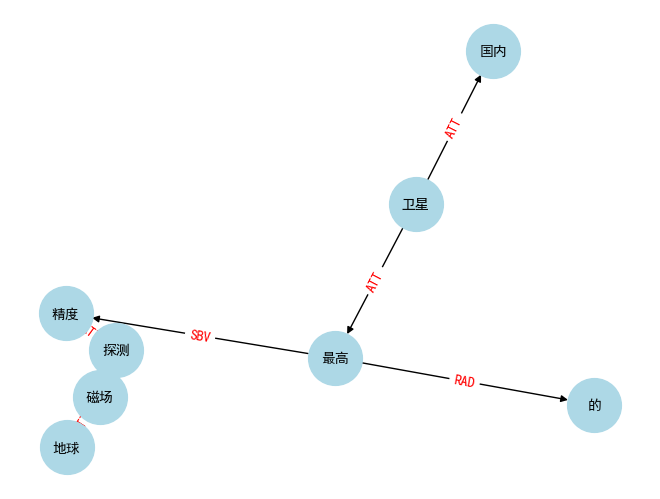

分词结果：[['将', '显著', '提高', '我国', '空间', '磁测', '技术', '水平']]
词性标注结果：[['d', 'a', 'v', 'n', 'n', 'j', 'n', 'n']]
命名实体识别结果：[[]]
语义角色标注结果：[[{'predicate': '提高', 'arguments': [('ARGM-ADV', '将'), ('ARGM-ADV', '显著'), ('A1', '我国空间磁测技术水平')]}]]
依存句法分析结果：[{'head': [3, 3, 0, 8, 7, 7, 8, 3], 'label': ['ADV', 'ADV', 'HED', 'ATT', 'ATT', 'ATT', 'ATT', 'VOB']}]
语义依存分析结果：[{'head': [3, 3, 0, 8, 7, 7, 8, 3], 'label': ['mDEPD', 'MANN', 'Root', 'FEAT', 'LOC', 'FEAT', 'FEAT', 'PAT']}]
语义依存图分析结果：[[(1, 3, 'mDEPD'), (2, 3, 'MANN'), (3, 0, 'Root'), (4, 8, 'FEAT'), (5, 7, 'LOC'), (6, 7, 'FEAT'), (7, 8, 'FEAT'), (8, 3, 'PAT')]]



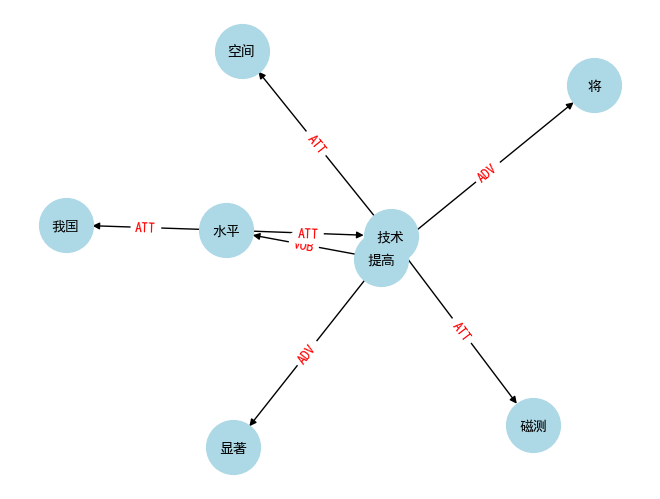

分词结果：[['该', '项目', '由', '国家', '航天局', '与', '澳门', '特别', '行政区', '政府', '联合', '开展']]
词性标注结果：[['r', 'n', 'p', 'n', 'n', 'p', 'ns', 'a', 'n', 'n', 'v', 'v']]
命名实体识别结果：[[('Ni', '国家航天局'), ('Ni', '澳门特别行政区')]]
语义角色标注结果：[[{'predicate': '开展', 'arguments': [('A1', '该项目'), ('A0', '由国家航天局与澳门特别行政区政府'), ('ARGM-ADV', '联合')]}]]
依存句法分析结果：[{'head': [2, 11, 11, 5, 3, 10, 9, 9, 10, 5, 0, 11], 'label': ['ATT', 'FOB', 'ADV', 'ATT', 'POB', 'LAD', 'ATT', 'ATT', 'ATT', 'COO', 'HED', 'COO']}]
语义依存分析结果：[{'head': [2, 12, 5, 5, 10, 10, 9, 9, 10, 12, 12, 0], 'label': ['SCO', 'CONT', 'mRELA', 'FEAT', 'eCOO', 'mRELA', 'FEAT', 'FEAT', 'FEAT', 'AGT', 'MANN', 'Root']}]
语义依存图分析结果：[[(1, 2, 'SCO'), (2, 12, 'CONT'), (3, 5, 'mRELA'), (4, 5, 'FEAT'), (5, 10, 'eCOO'), (6, 10, 'mRELA'), (7, 9, 'FEAT'), (8, 9, 'FEAT'), (9, 10, 'FEAT'), (10, 12, 'AGT'), (11, 0, 'Root'), (11, 12, 'MANN'), (12, 0, 'Root')]]



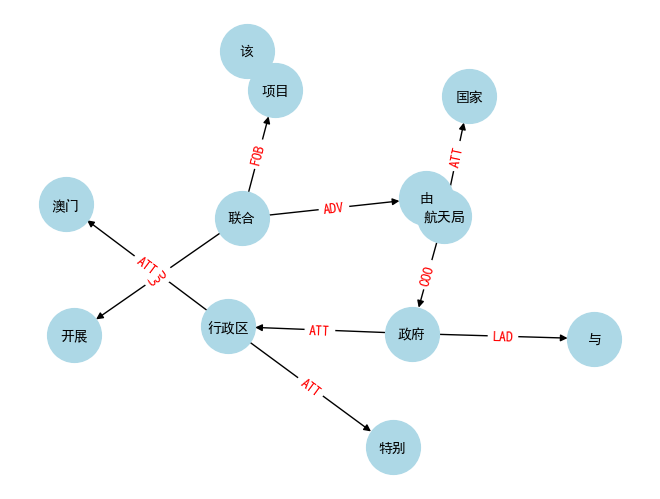

分词结果：[['探测', '数据', '由', '双方', '共享']]
词性标注结果：[['v', 'n', 'p', 'n', 'v']]
命名实体识别结果：[[]]
语义角色标注结果：[[{'predicate': '共享', 'arguments': [('A0', '由双方')]}]]
依存句法分析结果：[{'head': [2, 5, 5, 3, 0], 'label': ['ATT', 'FOB', 'ADV', 'POB', 'HED']}]
语义依存分析结果：[{'head': [2, 5, 4, 5, 0], 'label': ['FEAT', 'PAT', 'mRELA', 'AGT', 'Root']}]
语义依存图分析结果：[[(1, 2, 'FEAT'), (2, 5, 'PAT'), (3, 4, 'mRELA'), (4, 5, 'AGT'), (5, 0, 'Root')]]



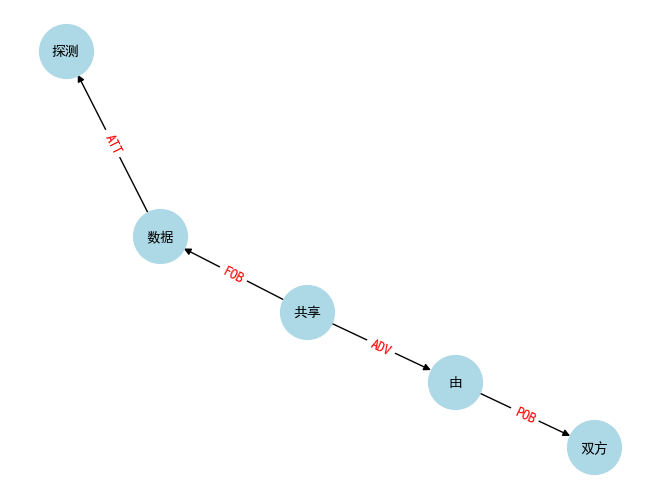

分词结果：[['开辟', '了', '内地', '同', '澳门', '在', '航天', '等', '创新', '科技', '领域', '开展', '合作', '的', '新', '路径']]
词性标注结果：[['v', 'u', 'nl', 'p', 'ns', 'p', 'n', 'u', 'v', 'n', 'n', 'v', 'v', 'u', 'a', 'n']]
命名实体识别结果：[[('Ns', '澳门')]]
语义角色标注结果：[[{'predicate': '开辟', 'arguments': [('A1', '内地同澳门在航天等创新科技领域开展合作的新路径')]}, {'predicate': '开展', 'arguments': [('A0', '内地'), ('A0-CRD', '同澳门'), ('ARGM-LOC', '在航天等创新科技领域'), ('A1', '合作'), ('ARGM-MNR', '路径')]}]]
依存句法分析结果：[{'head': [0, 1, 12, 12, 4, 12, 11, 7, 10, 11, 6, 16, 12, 12, 16, 1], 'label': ['HED', 'RAD', 'SBV', 'ADV', 'POB', 'ADV', 'ATT', 'RAD', 'ATT', 'ATT', 'POB', 'ATT', 'VOB', 'RAD', 'ATT', 'VOB']}]
语义依存分析结果：[{'head': [0, 1, 12, 5, 12, 11, 11, 7, 10, 11, 12, 16, 12, 12, 16, 1], 'label': ['Root', 'mDEPD', 'AGT', 'mRELA', 'DATV', 'mRELA', 'FEAT', 'mDEPD', 'FEAT', 'FEAT', 'LOC', 'dFEAT', 'CONT', 'mDEPD', 'FEAT', 'CONT']}]
语义依存图分析结果：[[(1, 0, 'Root'), (2, 1, 'mDEPD'), (3, 12, 'AGT'), (4, 5, 'mRELA'), (5, 12, 'DATV'), (6, 11, 'mRELA'), (7, 11, 'FEAT'), (8, 7, 'mDEPD

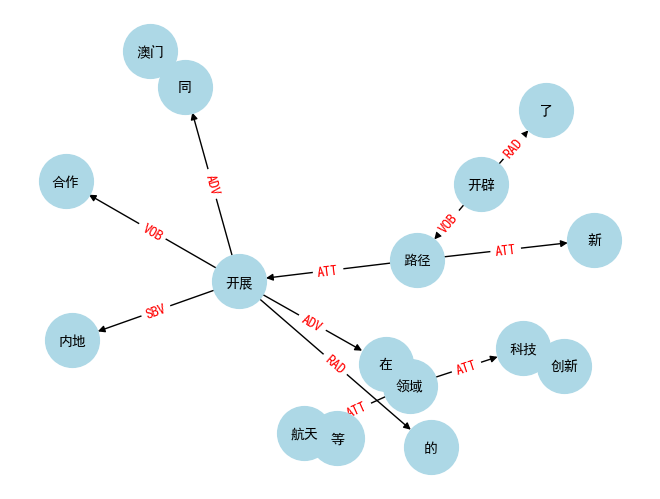

分词结果：[['拓展', '了', '以', '内地', '为', '基础', '、', '澳门', '为', '窗口', '开展', '空间科学', '、', '空间', '技术', '、', '空间', '应用', '广泛', '合作', '交流', '的', '新', '空间']]
词性标注结果：[['v', 'u', 'p', 'nl', 'v', 'n', 'wp', 'ns', 'v', 'nl', 'v', 'n', 'wp', 'n', 'n', 'wp', 'n', 'v', 'a', 'v', 'v', 'u', 'a', 'n']]
命名实体识别结果：[[('Ns', '澳门')]]
语义角色标注结果：[[{'predicate': '拓展', 'arguments': [('A1', '以内地为基础、澳门为窗口开展空间科学、空间技术、空间应用广泛合作交流的新空间')]}, {'predicate': '为', 'arguments': [('A2', '以内地'), ('A1', '基础')]}, {'predicate': '为', 'arguments': [('A2', '澳门'), ('A1', '窗口')]}, {'predicate': '开展', 'arguments': [('A1', '空间科学、空间技术、空间应用广泛合作交流')]}]]
依存句法分析结果：[{'head': [0, 1, 5, 3, 24, 5, 9, 9, 5, 9, 24, 20, 15, 15, 12, 18, 18, 12, 20, 11, 20, 11, 24, 1], 'label': ['HED', 'RAD', 'ADV', 'POB', 'ATT', 'VOB', 'WP', 'SBV', 'COO', 'VOB', 'ATT', 'FOB', 'WP', 'ATT', 'COO', 'WP', 'ATT', 'COO', 'ADV', 'VOB', 'COO', 'RAD', 'ATT', 'VOB']}]
语义依存分析结果：[{'head': [0, 1, 4, 5, 24, 5, 5, 9, 5, 9, 24, 15, 12, 15, 18, 15, 18, 20, 20, 11, 20, 11, 24, 1], 'label': 

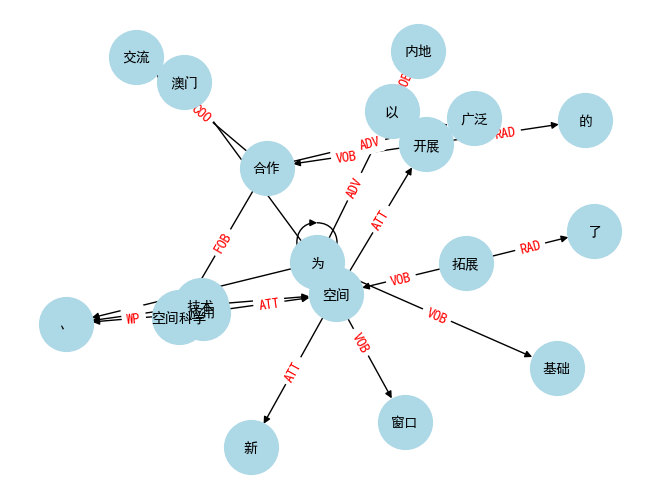

分词结果：[['为', '粤港澳', '大湾区', '区域', '发展', '和', '航天', '高', '质量', '发展', '增添', '了', '新', '动能']]
词性标注结果：[['p', 'j', 'n', 'n', 'v', 'c', 'n', 'a', 'n', 'v', 'v', 'u', 'a', 'n']]
命名实体识别结果：[[]]
语义角色标注结果：[[{'predicate': '增添', 'arguments': [('A2', '为粤港澳大湾区区域发展和航天高质量发展'), ('A1', '新动能')]}]]
依存句法分析结果：[{'head': [11, 3, 5, 5, 1, 10, 10, 9, 10, 5, 0, 11, 14, 11], 'label': ['ADV', 'ATT', 'ATT', 'ATT', 'POB', 'LAD', 'ATT', 'ATT', 'ATT', 'COO', 'HED', 'RAD', 'ATT', 'VOB']}]
语义依存分析结果：[{'head': [5, 3, 5, 5, 11, 10, 10, 9, 10, 11, 0, 11, 14, 11], 'label': ['mRELA', 'FEAT', 'LOC', 'FEAT', 'dDATV', 'mRELA', 'PAT', 'FEAT', 'EXP', 'DATV', 'Root', 'mDEPD', 'FEAT', 'EXP']}]
语义依存图分析结果：[[(1, 5, 'mRELA'), (1, 10, 'mRELA'), (2, 3, 'FEAT'), (3, 5, 'LOC'), (4, 5, 'FEAT'), (5, 11, 'dDATV'), (6, 10, 'mRELA'), (7, 10, 'PAT'), (8, 9, 'FEAT'), (9, 10, 'EXP'), (10, 11, 'DATV'), (11, 0, 'Root'), (12, 11, 'mDEPD'), (13, 14, 'FEAT'), (14, 11, 'EXP')]]



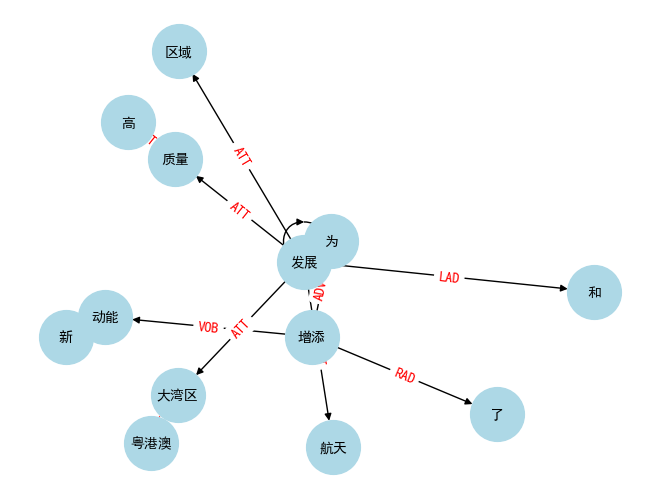

分词结果：[['“', '澳门', '科学', '一号', '”', '卫星', '项目', '鼓励', '科学', '数据', '的', '开放', '共享', '和', '应用']]
词性标注结果：[['wp', 'ns', 'n', 'm', 'wp', 'n', 'n', 'v', 'n', 'n', 'u', 'v', 'v', 'c', 'v']]
命名实体识别结果：[[('Ns', '澳门')]]
语义角色标注结果：[[{'predicate': '鼓励', 'arguments': [('A0', '“澳门科学一号”卫星项目'), ('A1', '科学数据的开放共享和应用')]}]]
依存句法分析结果：[{'head': [3, 3, 4, 7, 4, 7, 8, 0, 10, 12, 10, 8, 12, 15, 12], 'label': ['WP', 'ATT', 'ATT', 'ATT', 'WP', 'ATT', 'SBV', 'HED', 'ATT', 'ATT', 'RAD', 'VOB', 'COO', 'LAD', 'COO']}]
语义依存分析结果：[{'head': [3, 3, 4, 7, 4, 7, 8, 0, 10, 12, 10, 8, 12, 15, 12], 'label': ['mPUNC', 'FEAT', 'FEAT', 'FEAT', 'mPUNC', 'FEAT', 'AGT', 'Root', 'FEAT', 'PAT', 'mDEPD', 'dCONT', 'eCOO', 'mRELA', 'eCOO']}]
语义依存图分析结果：[[(1, 3, 'mPUNC'), (2, 3, 'FEAT'), (3, 4, 'FEAT'), (4, 7, 'FEAT'), (5, 4, 'mPUNC'), (6, 7, 'FEAT'), (7, 8, 'AGT'), (8, 0, 'Root'), (9, 10, 'FEAT'), (10, 12, 'PAT'), (11, 10, 'mDEPD'), (12, 8, 'dCONT'), (13, 12, 'eCOO'), (14, 15, 'mRELA'), (15, 12, 'eCOO')]]



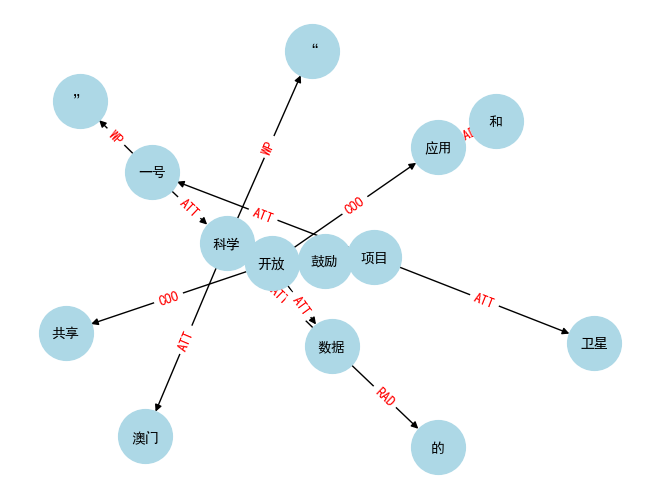

分词结果：[['将', '通过', '相关', '数据', '政策']]
词性标注结果：[['d', 'p', 'v', 'n', 'n']]
命名实体识别结果：[[]]
语义角色标注结果：[[{'predicate': '通过', 'arguments': [('ARGM-ADV', '将'), ('A1', '相关数据政策')]}]]
依存句法分析结果：[{'head': [2, 0, 5, 5, 2], 'label': ['ADV', 'HED', 'ATT', 'ATT', 'VOB']}]
语义依存分析结果：[{'head': [2, 0, 5, 5, 2], 'label': ['mDEPD', 'Root', 'FEAT', 'FEAT', 'CONT']}]
语义依存图分析结果：[[(1, 2, 'mDEPD'), (2, 0, 'Root'), (3, 5, 'FEAT'), (4, 5, 'FEAT'), (5, 2, 'CONT')]]



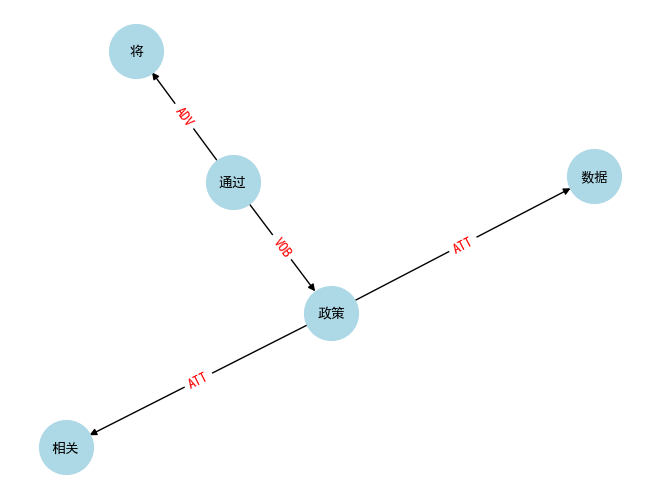

分词结果：[['促进', '与', '国内外', '科研', '机构', '开展', '广泛', '合作']]
词性标注结果：[['v', 'p', 'nl', 'n', 'n', 'v', 'a', 'v']]
命名实体识别结果：[[]]
语义角色标注结果：[[{'predicate': '促进', 'arguments': [('A1', '与国内外科研机构开展广泛合作')]}, {'predicate': '开展', 'arguments': [('A0-CRD', '与国内外科研机构'), ('A1', '广泛合作')]}]]
依存句法分析结果：[{'head': [0, 6, 5, 5, 2, 1, 8, 6], 'label': ['HED', 'ADV', 'ATT', 'ATT', 'POB', 'VOB', 'ADV', 'VOB']}]
语义依存分析结果：[{'head': [0, 5, 5, 5, 6, 1, 8, 6], 'label': ['Root', 'mRELA', 'LOC', 'FEAT', 'DATV', 'dCONT', 'FEAT', 'CONT']}]
语义依存图分析结果：[[(1, 0, 'Root'), (2, 5, 'mRELA'), (3, 5, 'LOC'), (4, 5, 'FEAT'), (5, 6, 'DATV'), (6, 1, 'dCONT'), (7, 8, 'FEAT'), (8, 6, 'CONT')]]



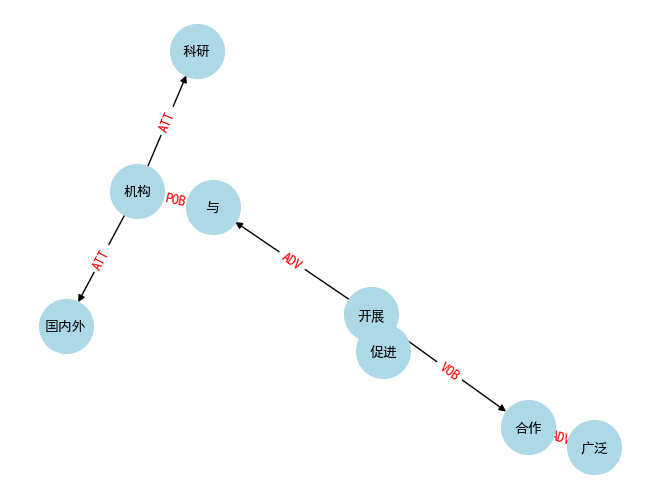

分词结果：[['产出', '更', '多', '科学', '研究', '成果']]
词性标注结果：[['v', 'd', 'a', 'n', 'v', 'n']]
命名实体识别结果：[[]]
语义角色标注结果：[[{'predicate': '产出', 'arguments': [('A1', '更多科学研究成果')]}]]
依存句法分析结果：[{'head': [0, 3, 6, 5, 6, 1], 'label': ['HED', 'ADV', 'ATT', 'ATT', 'ATT', 'VOB']}]
语义依存分析结果：[{'head': [0, 3, 6, 5, 6, 1], 'label': ['Root', 'mDEPD', 'MEAS', 'FEAT', 'FEAT', 'CONT']}]
语义依存图分析结果：[[(1, 0, 'Root'), (2, 3, 'mDEPD'), (3, 6, 'MEAS'), (4, 5, 'FEAT'), (5, 6, 'FEAT'), (6, 1, 'CONT')]]



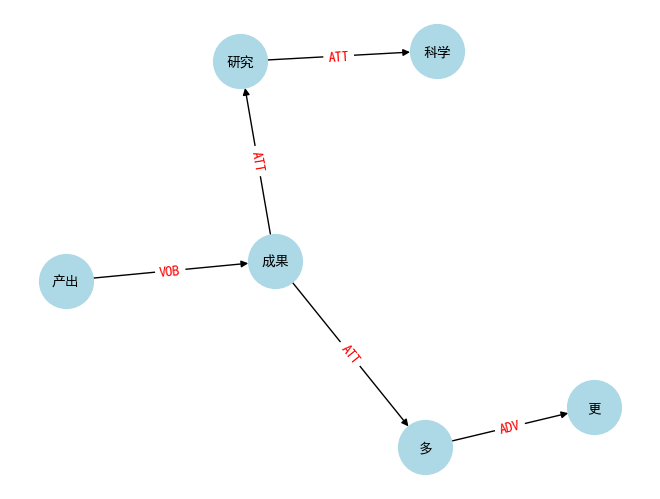

分词结果：[['加强', '人才', '联合', '培养', '和', '交流']]
词性标注结果：[['v', 'n', 'v', 'v', 'c', 'v']]
命名实体识别结果：[[]]
语义角色标注结果：[[{'predicate': '加强', 'arguments': [('A1', '人才联合培养和交流')]}]]
依存句法分析结果：[{'head': [0, 4, 4, 1, 6, 4], 'label': ['HED', 'FOB', 'ADV', 'VOB', 'LAD', 'COO']}]
语义依存分析结果：[{'head': [0, 4, 4, 1, 6, 4], 'label': ['Root', 'PAT', 'MANN', 'dCONT', 'mRELA', 'eCOO']}]
语义依存图分析结果：[[(1, 0, 'Root'), (2, 4, 'PAT'), (3, 4, 'MANN'), (4, 1, 'dCONT'), (5, 6, 'mRELA'), (6, 4, 'eCOO')]]



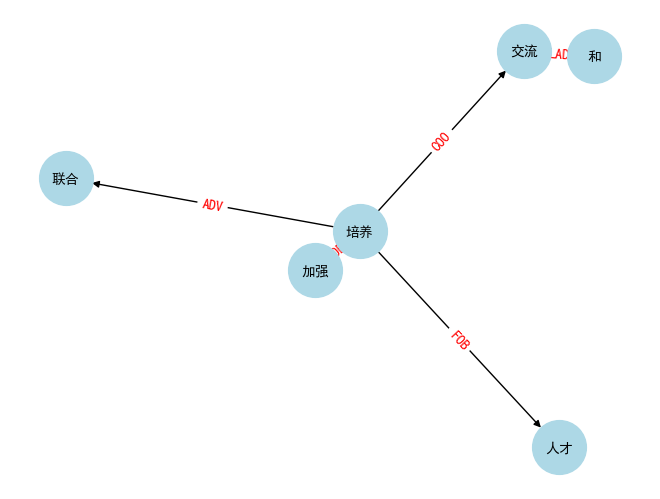

分词结果：[['未来', '还', '会', '持续', '推动', '航天', '科学', '研究', '与', '澳门', '青少年', '航天', '科普', '知识', '教育', '工作']]
词性标注结果：[['nt', 'd', 'v', 'v', 'v', 'n', 'n', 'v', 'c', 'ns', 'n', 'n', 'b', 'n', 'v', 'v']]
命名实体识别结果：[[('Ns', '澳门')]]
语义角色标注结果：[[{'predicate': '推动', 'arguments': [('ARGM-TMP', '未来'), ('ARGM-DIS', '还'), ('A1', '航天科学研究与澳门青少年航天科普知识教育工作')]}]]
依存句法分析结果：[{'head': [5, 3, 5, 5, 0, 7, 8, 5, 16, 11, 15, 14, 14, 15, 16, 8], 'label': ['ADV', 'ADV', 'ADV', 'ADV', 'HED', 'ATT', 'ATT', 'VOB', 'LAD', 'ATT', 'ATT', 'ATT', 'ATT', 'ATT', 'ATT', 'COO']}]
语义依存分析结果：[{'head': [5, 4, 4, 5, 0, 7, 8, 5, 16, 11, 15, 14, 14, 15, 16, 8], 'label': ['TIME', 'mDEPD', 'mDEPD', 'MANN', 'Root', 'FEAT', 'FEAT', 'PAT', 'mRELA', 'FEAT', 'DATV', 'FEAT', 'FEAT', 'DATV', 'FEAT', 'eCOO']}]
语义依存图分析结果：[[(1, 5, 'TIME'), (2, 4, 'mDEPD'), (3, 4, 'mDEPD'), (3, 5, 'mDEPD'), (4, 0, 'Root'), (4, 5, 'MANN'), (5, 0, 'Root'), (6, 7, 'FEAT'), (6, 8, 'FEAT'), (7, 8, 'FEAT'), (8, 5, 'PAT'), (9, 15, 'mRELA'), (9, 16, 'mRELA'), (10, 11, 'FEAT'

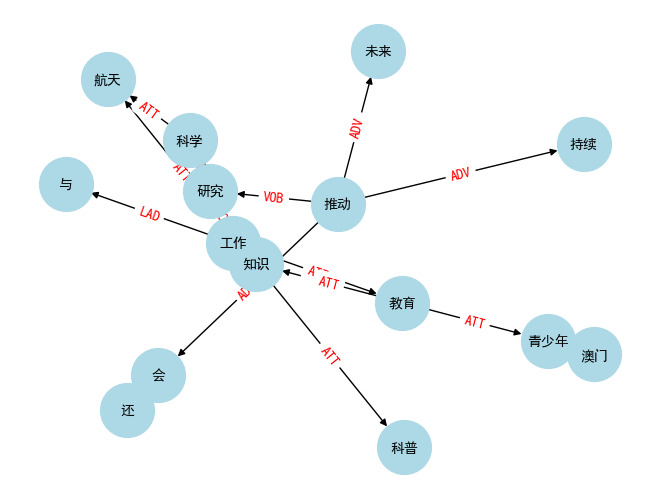

In [26]:
from ltp import LTP
import time
ltp = LTP('small1') # 使用本地下载的LTP模型`
for sent in sents:
    result = ltp.pipeline([sent], tasks=["cws", "pos", "ner", "srl", "dep", "sdp", "sdpg"])
    words, pos_tags, ner_tags, srl, dep, sdp, sdpg = result[0], result[1], result[2], result[3], result[4], result[5],result[6]
    print(f"分词结果：{words}")
    print(f"词性标注结果：{pos_tags}")
    print(f"命名实体识别结果：{ner_tags}")
    print(f"语义角色标注结果：{srl}")
    print(f"依存句法分析结果：{dep}")
    print(f"语义依存分析结果：{sdp}")
    print(f"语义依存图分析结果：{sdpg}\n")
    plot_dependency_graph(words[0], dep[0]['head'], dep[0]['label'])

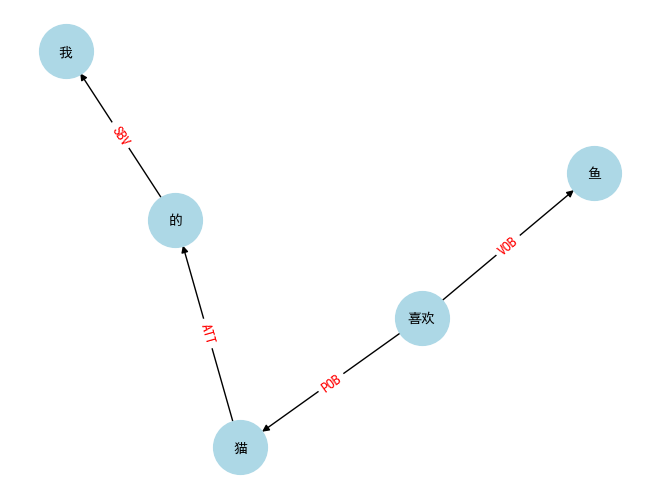

In [27]:
import networkx as nx
import matplotlib.pyplot as plt

# 示例数据
words = ['我', '的', '猫', '喜欢', '鱼']
heads = [2, 3, 4, 0, 4]  # 0 表示根节点
labels = ['SBV', 'ATT', 'POB', 'HED', 'VOB']

plot_dependency_graph(words, heads, labels)



In [28]:
with open('ltp_results.txt', 'w', encoding='utf-8') as file:
    for sent in sents:
            result = ltp.pipeline([sent], tasks=["cws", "pos", "ner", "srl", "dep", "sdp", "sdpg"])
            words, pos_tags, ner_tags, srl, dep, sdp, sdpg = result[0], result[1], result[2], result[3], result[4], result[5], result[6]

            # 将结果写入文件
            file.write(f"分词结果：{words}\n")
            file.write(f"词性标注结果：{pos_tags}\n")
            file.write(f"命名实体识别结果：{ner_tags}\n")
            file.write(f"语义角色标注结果：{srl}\n")
            file.write(f"依存句法分析结果：{dep}\n")
            file.write(f"语义依存分析结果：{sdp}\n")
            file.write(f"语义依存图分析结果：{sdpg}\n\n")